<a href="https://colab.research.google.com/github/cs24dse007-boop/CSL701-CS04-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Omkar Madhukar Bhalekar

Batch :CS1


Roll Number :CS04



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv("data.csv")

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())


First 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perim

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Diagnosis Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis Class Percentage:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


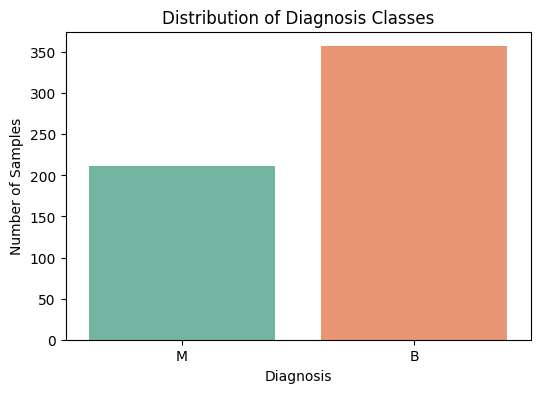

In [2]:
# ==========================================
# Task 2: Explore the Dataset
# ==========================================

# 1. Inspect dataset information and data types
print("Dataset Information:")
df.info()

# 2. Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# 3. Display summary statistics
print("\nSummary Statistics:")
display(df.describe())

# 4. Check target class distribution
print("\nDiagnosis Class Distribution:")
print(df["diagnosis"].value_counts())

# 5. Calculate percentage of each class
print("\nDiagnosis Class Percentage:")
print(df["diagnosis"].value_counts(normalize=True) * 100)

# 6. Visualize target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="diagnosis",
    hue="diagnosis",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Diagnosis Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [3]:
# ==========================================
# Task 3: Data Cleaning and Feature Selection
# ==========================================

# 1. Drop unnecessary metadata columns
df = df.drop(columns=["id", "Unnamed: 32"])

# 2. Convert diagnosis into numerical values
# M (Malignant) = 1
# B (Benign) = 0
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# 3. Separate features (X) and target (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# 4. Display shapes
print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

# 5. Display first few rows
print("\nFeature matrix X:")
display(X.head())

print("\nTarget vector y:")
display(y.head())


Shape of feature matrix X: (569, 30)
Shape of target vector y: (569,)

Feature matrix X:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target vector y:


,diagnosis
0,1
1,1
2,1
3,1
4,1


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [4]:
# ==========================================
# Task 4: Standardize Features
# ==========================================

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Standardize the feature matrix
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easy inspection
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print("Standardized Feature Matrix:")
display(X_scaled.head())


Standardized Feature Matrix:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [5]:
# ==========================================
# Task 5: PCA - 30D to 2D
# ==========================================

from sklearn.decomposition import PCA

# Create PCA object with 2 principal components
pca = PCA(n_components=2)

# Fit PCA and transform the standardized data
X_pca = pca.fit_transform(X_scaled)

# Display the shape of the transformed data
print("Original feature shape:", X_scaled.shape)
print("PCA-transformed shape:", X_pca.shape)


Original feature shape: (569, 30)
PCA-transformed shape: (569, 2)


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [6]:
# ==========================================
# Task 6: Explained Variance Ratio
# ==========================================

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Calculate cumulative variance
cumulative_variance = np.cumsum(explained_variance)

# Print results
print("Explained Variance Ratio:")
print(f"PC1: {explained_variance[0]:.4f} "
      f"({explained_variance[0] * 100:.2f}%)")

print(f"PC2: {explained_variance[1]:.4f} "
      f"({explained_variance[1] * 100:.2f}%)")

print("\nCumulative Variance Retained:")
print(f"PC1: {cumulative_variance[0]:.4f} "
      f"({cumulative_variance[0] * 100:.2f}%)")

print(f"PC1 + PC2: {cumulative_variance[1]:.4f} "
      f"({cumulative_variance[1] * 100:.2f}%)")


Explained Variance Ratio:
PC1: 0.4427 (44.27%)
PC2: 0.1897 (18.97%)

Cumulative Variance Retained:
PC1: 0.4427 (44.27%)
PC1 + PC2: 0.6324 (63.24%)


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

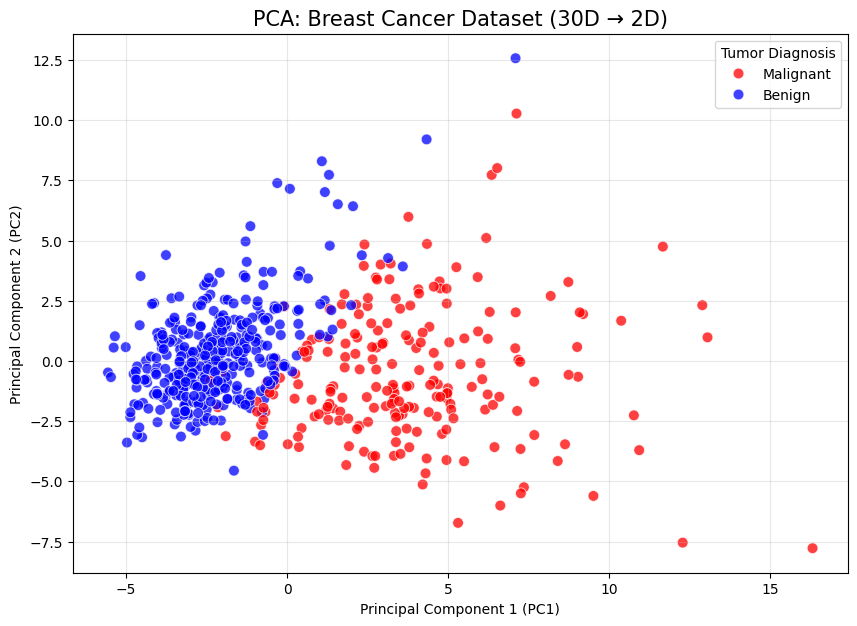

In [7]:
# ==========================================
# Task 7: PCA 2D Scatter Plot
# ==========================================

# Create a DataFrame containing PCA results and diagnosis
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add diagnosis labels
pca_df["Diagnosis"] = y.map({
    0: "Benign",
    1: "Malignant"
}).values

# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette={
        "Benign": "blue",
        "Malignant": "red"
    },
    alpha=0.75,
    s=60
)

plt.title("PCA: Breast Cancer Dataset (30D → 2D)", fontsize=15)
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Tumor Diagnosis")
plt.grid(True, alpha=0.3)

plt.show()


# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [8]:
# ==========================================
# Task 8: Logistic Regression on 30 Features
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------
# 1. Split the standardized 30-feature dataset
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# ------------------------------------------------
# 2. Create and train Logistic Regression model
# ------------------------------------------------

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

# ------------------------------------------------
# 3. Make predictions
# ------------------------------------------------

y_pred = log_reg.predict(X_test)

# ------------------------------------------------
# 4. Calculate baseline performance metrics
# ------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nBaseline Performance on 30 Features:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


Training set shape: (455, 30)
Testing set shape: (114, 30)

Baseline Performance on 30 Features:
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1-Score : 0.9512


# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [9]:
# ==========================================
# Task 9: Logistic Regression on PCA Data
# ==========================================

# X_pca contains the two features: PC1 and PC2

# 1. Split PCA-transformed data into training and testing sets
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("PCA Training set shape:", X_pca_train.shape)
print("PCA Testing set shape:", X_pca_test.shape)

# ------------------------------------------------
# 2. Create Logistic Regression model
# ------------------------------------------------

log_reg_pca = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg_pca.fit(X_pca_train, y_pca_train)

# ------------------------------------------------
# 3. Make predictions
# ------------------------------------------------

y_pca_pred = log_reg_pca.predict(X_pca_test)

# ------------------------------------------------
# 4. Calculate performance metrics
# ------------------------------------------------

pca_accuracy = accuracy_score(y_pca_test, y_pca_pred)
pca_precision = precision_score(y_pca_test, y_pca_pred)
pca_recall = recall_score(y_pca_test, y_pca_pred)
pca_f1 = f1_score(y_pca_test, y_pca_pred)

print("\nLogistic Regression Performance using PC1 and PC2:")
print(f"Accuracy : {pca_accuracy:.4f}")
print(f"Precision: {pca_precision:.4f}")
print(f"Recall   : {pca_recall:.4f}")
print(f"F1-Score : {pca_f1:.4f}")


PCA Training set shape: (455, 2)
PCA Testing set shape: (114, 2)

Logistic Regression Performance using PC1 and PC2:
Accuracy : 0.9386
Precision: 0.9730
Recall   : 0.8571
F1-Score : 0.9114


# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [10]:
# ==========================================
# Task 10: Compare Classifier Performance
# ==========================================

# Calculate metrics for the 30-feature model
accuracy_raw = accuracy_score(y_test, y_pred)
precision_raw = precision_score(y_test, y_pred)
recall_raw = recall_score(y_test, y_pred)
f1_raw = f1_score(y_test, y_pred)

# Calculate metrics for the PCA model
accuracy_pca = accuracy_score(y_pca_test, y_pca_pred)
precision_pca = precision_score(y_pca_test, y_pca_pred)
recall_pca = recall_score(y_pca_test, y_pca_pred)
f1_pca = f1_score(y_pca_test, y_pca_pred)

# Create comparison table
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Before PCA (30 Features)": [
        accuracy_raw,
        precision_raw,
        recall_raw,
        f1_raw
    ],
    "After PCA (2 Components)": [
        accuracy_pca,
        precision_pca,
        recall_pca,
        f1_pca
    ]
})

# Display values as percentages
comparison_display = comparison.copy()

comparison_display[
    ["Before PCA (30 Features)", "After PCA (2 Components)"]
] = comparison_display[
    ["Before PCA (30 Features)", "After PCA (2 Components)"]
].applymap(lambda x: f"{x * 100:.2f}%")

display(comparison_display)


/tmp/ipykernel_1615/2415689355.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ].applymap(lambda x: f"{x * 100:.2f}%")


,Metric,Before PCA (30 Features),After PCA (2 Components)
0,Accuracy,96.49%,93.86%
1,Precision,97.50%,97.30%
2,Recall,92.86%,85.71%
3,F1-Score,95.12%,91.14%


# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.